In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
import os

train_dir = "../dataset/processed/train"
test_dir = "../dataset/processed/test"

class_names = sorted(os.listdir(train_dir))

print("Class:", class_names)
print("Jumlah class:", len(class_names))

Class: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Jumlah class: 7


In [4]:
import pandas as pd

train_df = pd.read_csv("../dataset/train_split.csv")
val_df = pd.read_csv("../dataset/val_split.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 21947
Validation: 5487


In [5]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label_index"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label_index"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    len(train_df),
    seed=42
).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [6]:
images, labels = next(iter(train_dataset))

print("Shape images:", images.shape)
print("Shape labels:", labels.shape)
print("Pixel min:", tf.reduce_min(images).numpy())
print("Pixel max:", tf.reduce_max(images).numpy())

Shape images: (32, 48, 48, 1)
Shape labels: (32,)
Pixel min: 0.0
Pixel max: 1.0


In [7]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(48, 48, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(7, activation="softmax")
])

model.summary()

d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20


d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


686/686 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.3190 - loss: 1.7074 - val_accuracy: 0.3909 - val_loss: 1.5907
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.4015 - loss: 1.5410 - val_accuracy: 0.4502 - val_loss: 1.4302
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.4415 - loss: 1.4503 - val_accuracy: 0.4625 - val_loss: 1.3815
Epoch 4/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.4624 - loss: 1.3962 - val_accuracy: 0.4833 - val_loss: 1.3484
Epoch 5/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.4815 - loss: 1.3445 - val_accuracy: 0.4830 - val_loss: 1.3302
Epoch 6/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.5027 - loss: 1.2944 - val_accuracy: 0.5008 - val_loss: 1.3153
Epoch 7/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.5177 - loss: 1.2483 - val_accuracy: 0.4862 - val_loss: 1.3206
Epoch 8/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.5352 - loss: 1.2099 - val_accurac

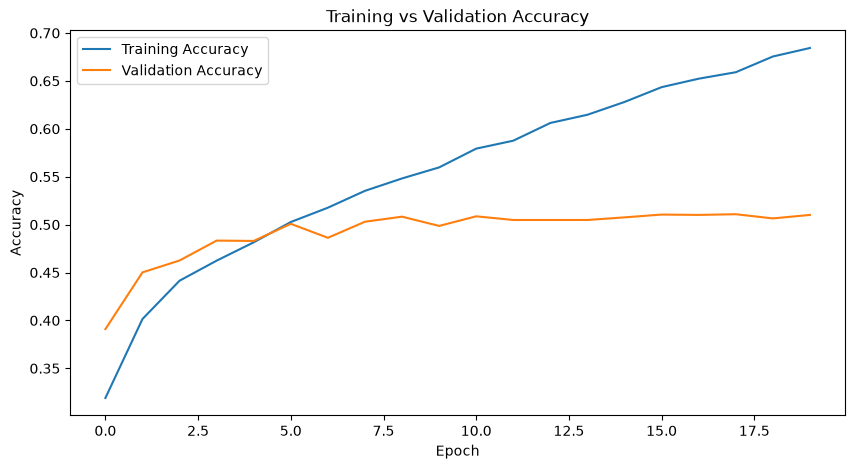

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

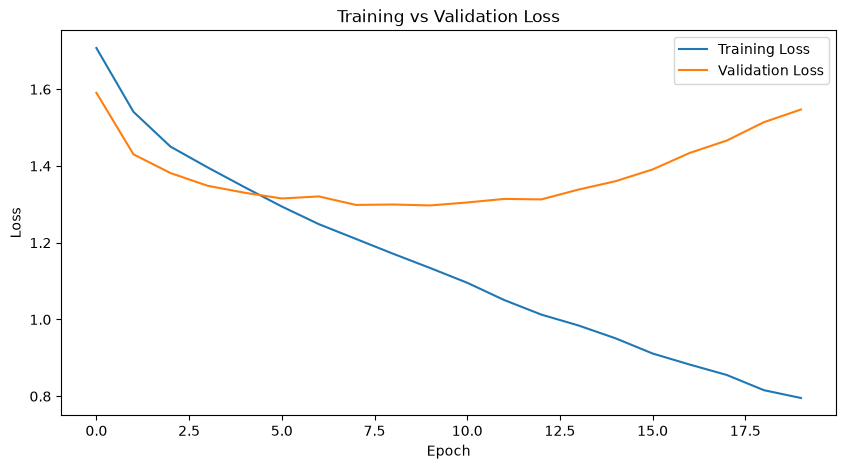

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Jumlah data validation:", len(y_true))

Jumlah data validation: 5487


In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       angry       0.39      0.36      0.38       767
     disgust       0.71      0.07      0.12        76
        fear       0.38      0.27      0.32       777
       happy       0.70      0.77      0.73      1417
     neutral       0.47      0.52      0.49       973
         sad       0.37      0.45      0.41       943
    surprise       0.65      0.54      0.59       534

    accuracy                           0.51      5487
   macro avg       0.53      0.42      0.43      5487
weighted avg       0.51      0.51      0.50      5487



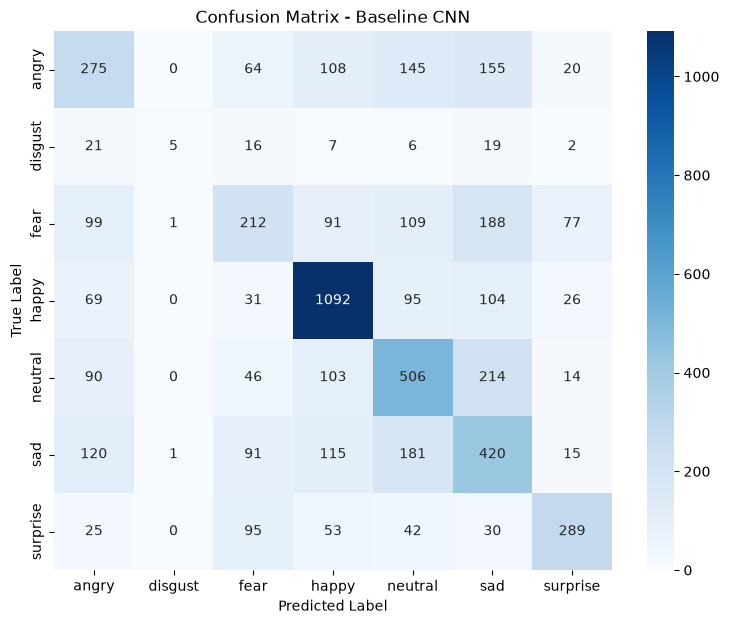

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Baseline CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()